In [11]:
from pathlib import Path
import yaml
import os 
os.chdir(Path('/gpfs-calypso/home/globc/garcia/'))
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import glob
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy import stats
from cartopy.util import add_cyclic_point
from math import ceil
import matplotlib.colors as mcolors

from matplotlib import ticker



from scenarIA.src.utils.plotutils import plot_map_contour
from scenarIA.src.data.dataloader import get_climatology
from scenarIA.src.utils.evalutils import EvaluationPlots, compare_temporal_profiles, compare_metrics_maps, compare_metrics
from scenarIA.src.utils.datautils import dataset_xr_formatting, weighted_global_mean
from scenarIA.src.utils.settings import PREDICTIONS_DIR, DATASET_DIR, GRAPHS_DIR, CONFIG_DIR, SIMUS_COLORS_DICT

with open(CONFIG_DIR / 'plots.yaml') as file:
    config_plots = yaml.safe_load(file)

In [12]:
true_simu = 'ssp245'

In [13]:

save_dir = GRAPHS_DIR/ f'runs/MPI-ESM1-2-LR/annual/exp9' # or None
#save_dir = None
pred_path = PREDICTIONS_DIR / f'MPI-ESM1-2-LR/annual/exp9'
title_base = 'MPI-ESM1-2-LR_annual_exp9_regional_study_aer_'
simus_dict = {'ssp245': {'color': 'royalblue',
                        'mean_error': [-10., 10.],
                        'values': [-40., 40.],
                        'std': [0, 600.]},
            'ssp370': {'color': 'red',
                        'mean_error': [-1, 1],
                        'values': [-2.4, 2.4],
                        'std': [0, 0.3]}}

europe_proj = ccrs.RotatedPole(pole_latitude=39.25, pole_longitude=-162.0)
se_asia_proj = ccrs.LambertConformal(central_longitude=105, central_latitude=35)

## Regional relative precipitation changes 

In [14]:

var_name = 'pr'
# Open true projection file
true = xr.open_dataset( DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{true_simu}.nc').mean('member') # 50 members
lats = true.lat.values
lons = true.lon.values
t = true.time.values
y = true[var_name]

# Open prediction files to compare
y_hat_ds_dict = {'CNN-LSTM': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_cnn-lstm_seq5_mem30_epoch100_bs4_clim.nc')['pr'],
        'ConvGRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_convgru_seq5_mem30_epoch100_bs4_clim.nc')['pr'],
        'Attention-UNet' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_attention-unet_seq5_mem30_epoch100_bs4_clim_64.nc')['pr'],
        'Pattern-Scaling' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_pattern-scaling_seq1_mem30.nc')['pr']}


In [15]:
# Open climatology file for pr
clim = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_piControl.nc').mean('member')
clim = clim.sel(time=slice('1850-01-01', '2250-12-31')).mean('time')['pr'].values

In [16]:
def regional_maps(data, lat, lon, lims, title, cmap='BrBG', label='',ncols=2, nrows=None, 
                  domain=[0,360,-90,90], figsize_per_ax=(6, 6), log_scale=False, projection= ccrs.Robinson(), save_dir=None):
    """
    data : dict {nom_du_test: carte 2D (lat, lon)}
    lat, lon : coordonnées communes à toutes les cartes
    lims : (vmin, vmax) pour les niveaux de contour / colorbar, ou None
    title : titre général de la figure
    ncols, nrows : nombre de colonnes / lignes du subplot. Si nrows=None, calculé automatiquement.
    """
    n_tests = len(data)

    if nrows is None:
        nrows = ceil(n_tests / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_ax[0] * ncols, figsize_per_ax[1] * nrows),
        subplot_kw={"projection": projection}
    )
    # uniformiser en tableau 1D d'axes, même s'il n'y a qu'un seul subplot
    axes = np.atleast_1d(axes).flatten()

    if lims is not None:
        if log_scale:
            #levels = np.geomspace(lims[0], lims[1], 10)
            levels = np.geomspace(lims[0], lims[1], 9)
            norm = mcolors.LogNorm(vmin=lims[0], vmax=lims[1])
        else:
            levels = np.linspace(lims[0], lims[1], 9)
            norm = None
            
    else:
        levels = None
        norm = None

    

    cs = None
    for ax, (name, arr) in zip(axes, data.items()):
        
        if log_scale: # Sinon on traite les données nulles comme des nan
            floor_value = lims[0]
            arr = np.where(arr <= 0, floor_value, arr)
        data_cyclic, lon_cyclic = add_cyclic_point(arr, coord=lon)  # because lon_max = 358.1
        
        
        cs = ax.contourf(
            lon_cyclic,
            lat,
            data_cyclic,
            cmap=cmap,
            levels=levels,
            transform=ccrs.PlateCarree(),
            extend='both',
            norm=norm
        )
        ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1, zorder=10, alpha=0.7)
        ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.6)

        if domain != [0,360,-90,90]:
            ax.set_extent(domain, crs=ccrs.PlateCarree())
        ax.gridlines(
            draw_labels=False,
            linewidth=0.5,
            color="gray"
        )
        ax.set_title(name)

    # désactiver les axes vides si le nombre de tests ne remplit pas toute la grille
    for ax in axes[n_tests:]:
        ax.axis('off')

    fig.suptitle(title, fontsize=16)

    # une seule colorbar pour l'ensemble des subplots utilisés
    cbar = fig.colorbar(
        cs,
        ax=axes[:n_tests].tolist(),
        pad=0.05,
        shrink=0.7,
        orientation='vertical'
    )
    cbar.set_label(label, fontsize=14)
    cbar.ax.tick_params(labelsize=14)
    if lims is not None:
        if log_scale:
            cbar.ax.yaxis.set_major_locator(ticker.LogLocator(base=10, subs=(1,)))
            cbar.ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs='all'))
            cbar.ax.yaxis.set_minor_formatter(ticker.NullFormatter())

            def log_fmt(x, pos):
                exponent = int(round(np.log10(x)))
                return r'$10^{%d}$' % exponent

            cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(log_fmt))
        else:
            ticks = np.linspace(lims[0], lims[1], 5)
            cbar.set_ticks(ticks)
            
            cbar.set_ticklabels([str(round(float(i), 2 if log_scale else 1)) for i in ticks])

    if save_dir:
        plt.savefig(save_dir / f'{title}_regional_maps.png')


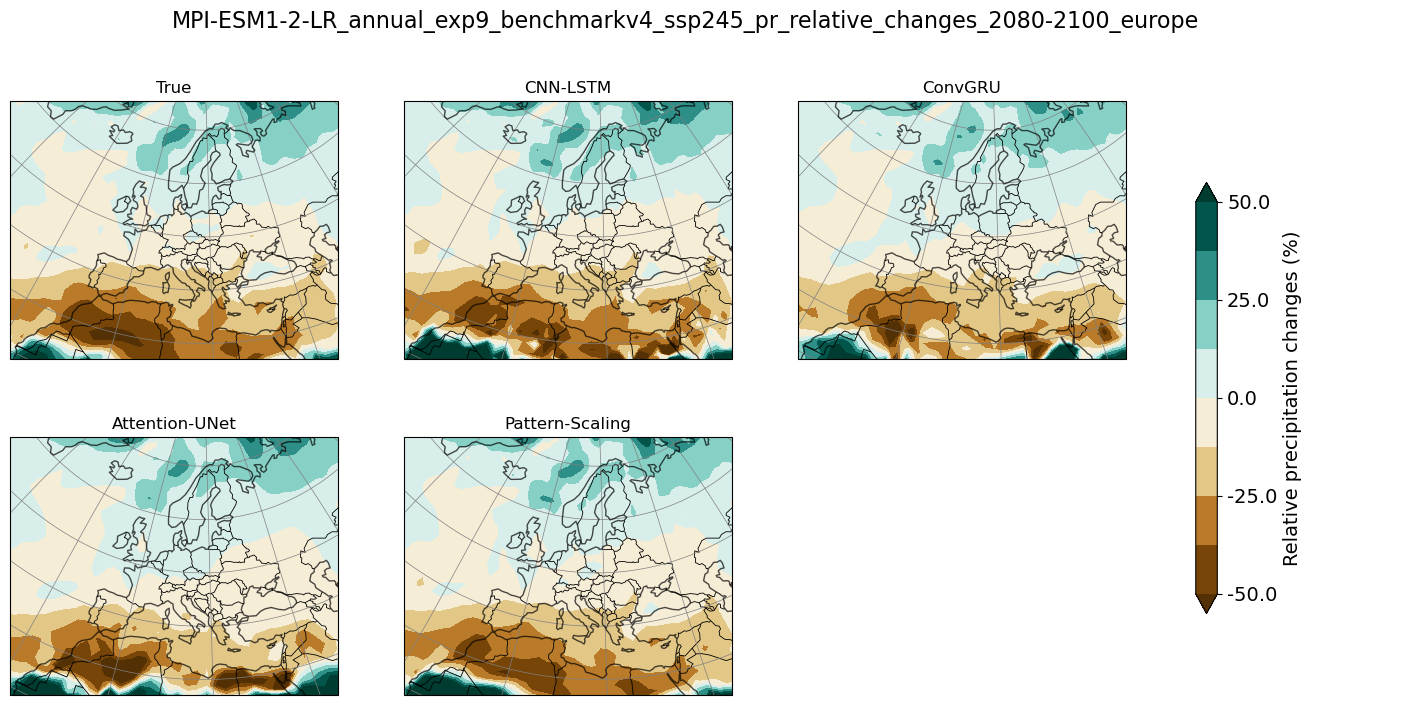

In [7]:
# Relative changes
domain= [-22, 45, 27, 72]
lims = [-50, 50]

data = {}
data['True'] = (y.sel(time=slice('2080', '2100')).mean(dim='time').values - clim) / clim * 100
for test, y_hat in y_hat_ds_dict.items():
    data[test] = (y_hat.sel(time=slice('2080', '2100')).mean('time').mean('run').values - clim) / clim * 100

regional_maps(data,
             y.lat.values,
             y.lon.values,
             lims=lims,
             title=title_base + 'ssp245_pr_relative_changes_2080-2100_europe',
              domain=domain,
            label='Relative precipitation changes (%)',
             ncols=3, nrows=None, figsize_per_ax=(6, 4),
             projection=europe_proj,
             save_dir= save_dir)

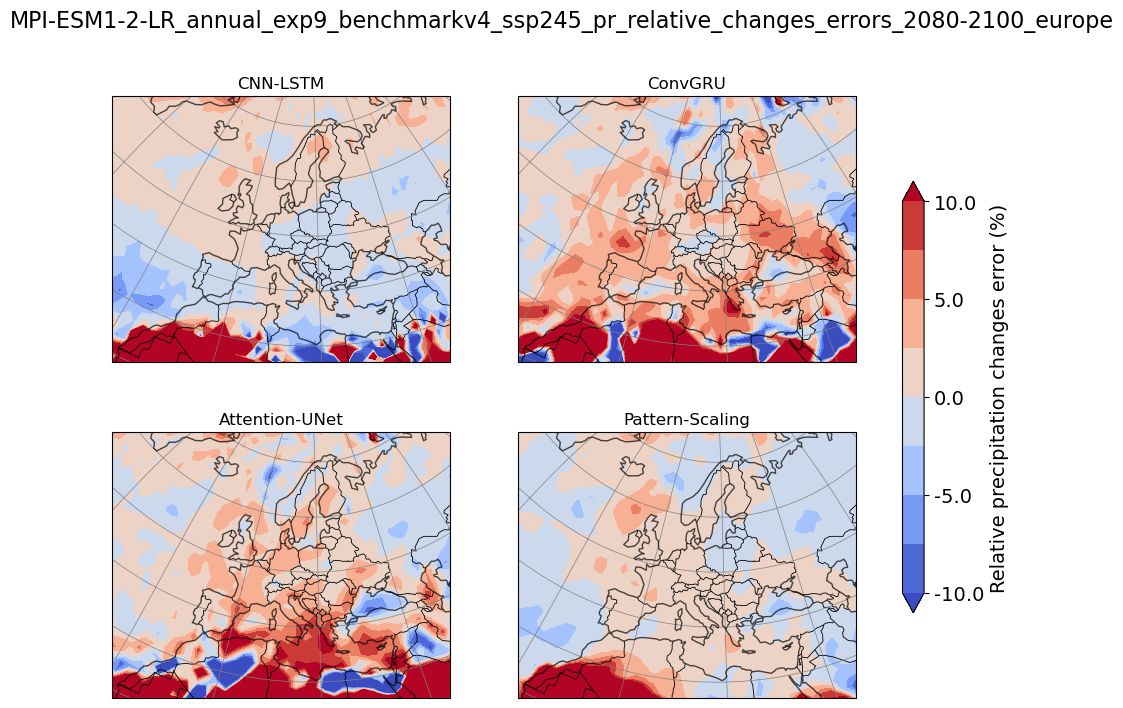

In [8]:
# Relative changes errors

lims = [-10, 10]

data = {}
y_relative_changes = (y.sel(time=slice('2080', '2100')).mean(dim='time').values - clim) / clim * 100
for test, y_hat in y_hat_ds_dict.items():
    data[test] = (y_hat.sel(time=slice('2080', '2100')).mean('time').mean('run').values - clim) / clim * 100 - y_relative_changes

regional_maps(data,
             y.lat.values,
             y.lon.values,
             lims=lims,
             title=title_base +'ssp245_pr_relative_changes_errors_2080-2100_europe',
              domain=domain,
              label='Relative precipitation changes error (%)',
             cmap='coolwarm',
             ncols=2, nrows=None, figsize_per_ax=(6, 4),
             projection=europe_proj,
             save_dir=save_dir)

## Aerosols influence on tas regional response (ssp245-aer)

In [9]:
so2 = xr.open_dataset(DATASET_DIR / 'MPI-ESM1-2-LR/annual/inputs_ssp245-aer_regrid2.nc')['SO2']
y_hat_ds_dict = {'CNN-GRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_ssp245-aer_tas_cnn-gru_seq10_mem30_epoch100_bs16_clim.nc')['tas'],
        'Attention-UNet' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_ssp245-aer_tas_attention-unet_seq10_mem30_epoch100_bs16_clim.nc')['tas'],
        'Pattern-Scaling' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_ssp245-aer_tas_pattern-scaling_seq1_mem30.nc')['tas']}

# Open climatology file for pr
clim = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_piControl.nc').mean('member')
clim = clim.sel(time=slice('1850-01-01', '2250-12-31')).mean('time')['tas'].values

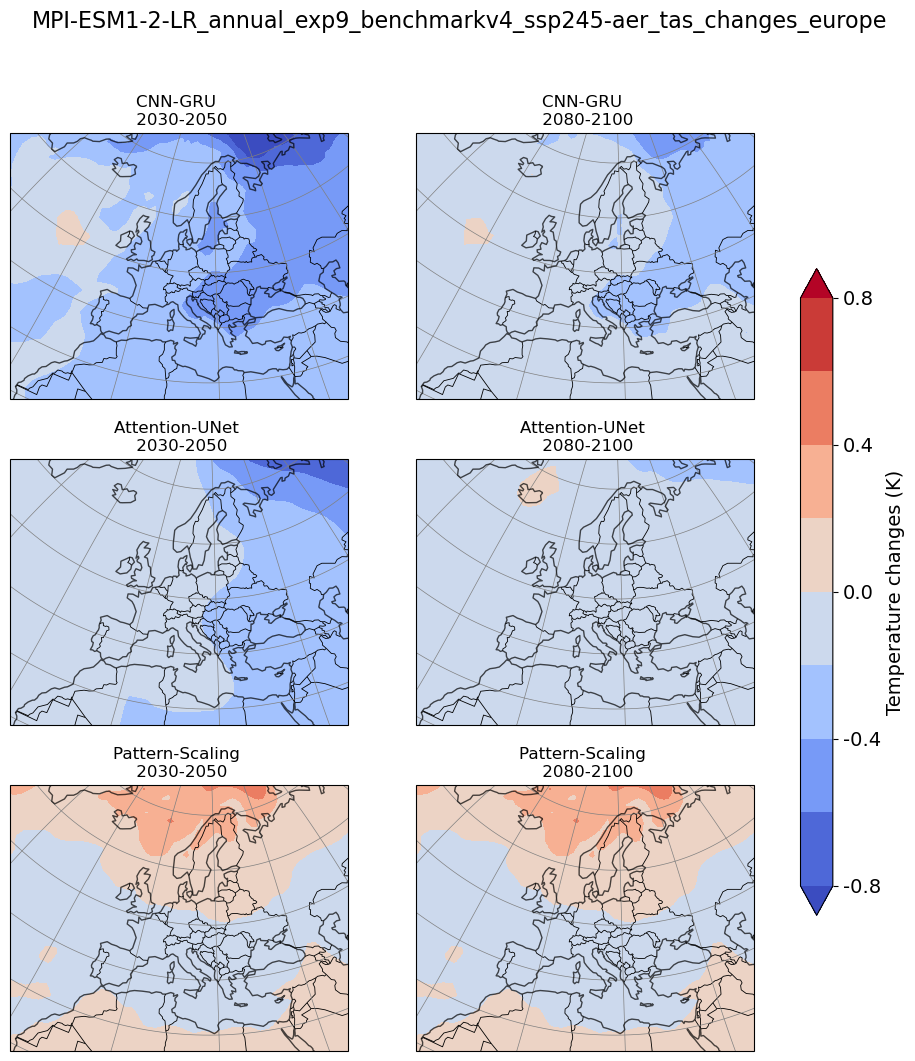

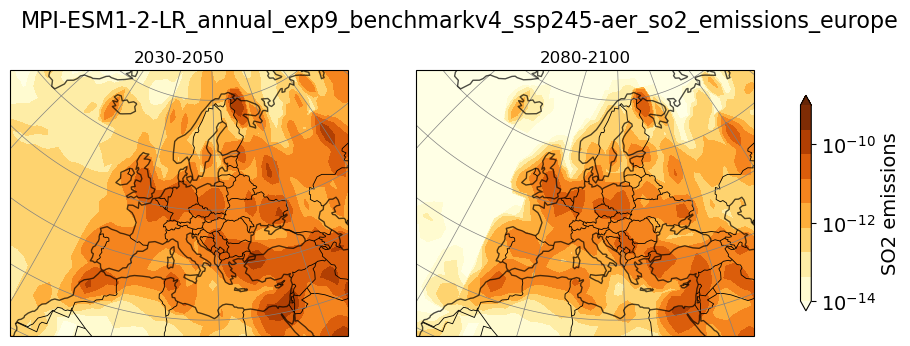

In [10]:
# Relative changes
domain= [-22, 45, 27, 72] # Euro-Cordex
lims = [-0.75, 0.75]

# 2030-2050
data = {}
for test, y_hat in y_hat_ds_dict.items():
    data[f'{test} \n 2030-2050'] = (y_hat.sel(time=slice('2030', '2050')).mean('time').mean('run').values - clim) ### 10 first year to remove
    data[f'{test} \n 2080-2100'] = (y_hat.sel(time=slice('2080', '2100')).mean('time').mean('run').values - clim) ### 10 first year to remove

regional_maps(data,
             lats,
             lons,
             lims=lims,
             title=title_base +'ssp245-aer_tas_changes_europe',
              domain=domain,
              cmap='coolwarm',
            label='Temperature changes (K)',
             ncols=2, nrows=None, figsize_per_ax=(6, 4),projection=europe_proj,
             save_dir=save_dir)

data_dict = {'2030-2050':so2.sel(time=slice('2030', '2050')).mean('time').values,
             '2080-2100':so2.sel(time=slice('2080', '2100')).mean('time').values}
regional_maps(data_dict,
             so2.lat.values,
             so2.lon.values,
             lims=[10e-15, 10e-10],
              domain=domain,
             title=title_base +'ssp245-aer_so2_emissions_europe',
              label='SO2 emissions',
             cmap='YlOrBr',
             ncols=2, nrows=None, figsize_per_ax=(6, 4),
             log_scale=True,projection=europe_proj,
             save_dir=save_dir)

<xarray.DataArray 'SO2' (time: 86, lat: 25, lon: 36)> Size: 619kB
[77400 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 688B 2015-01-01 2016-01-01 ... 2100-01-01
  * lat      (lat) float64 200B 27.05 28.91 30.78 32.64 ... 68.08 69.95 71.81
  * lon      (lon) float64 288B -20.62 -18.75 -16.88 -15.0 ... 41.25 43.12 45.0


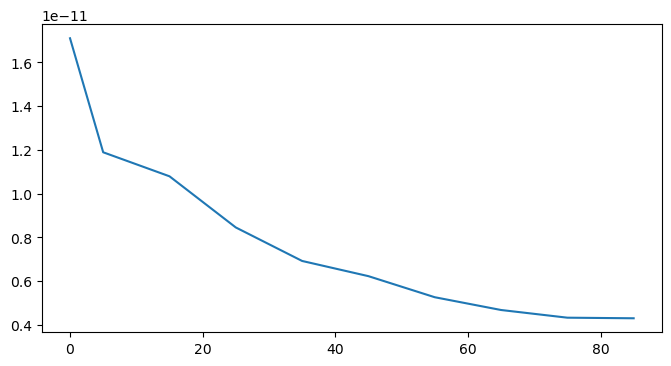

In [11]:
so2 = so2.assign_coords(lon=((so2.lon + 180) % 360) - 180)
so2 = so2.sortby('lon')
so2_regional = so2.sel(lon=slice(-22, 45) ,lat=slice( 27, 72))
print(so2_regional)
plt.figure(figsize=(8,4))
plt.plot(weighted_global_mean(so2_regional))

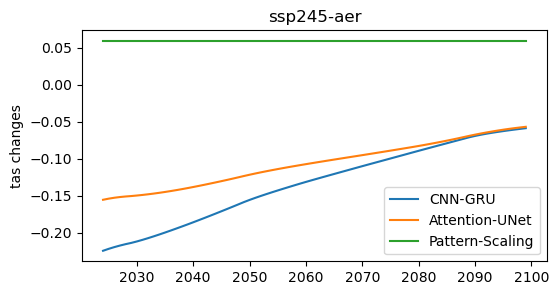

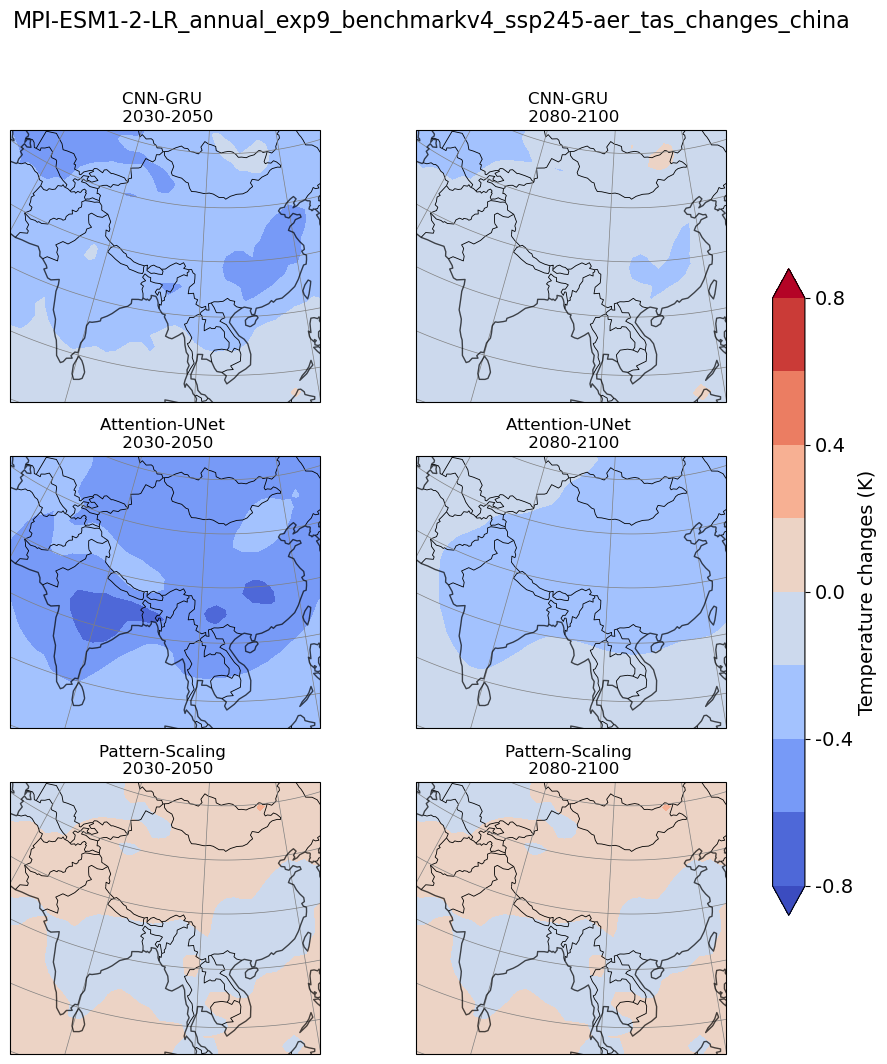

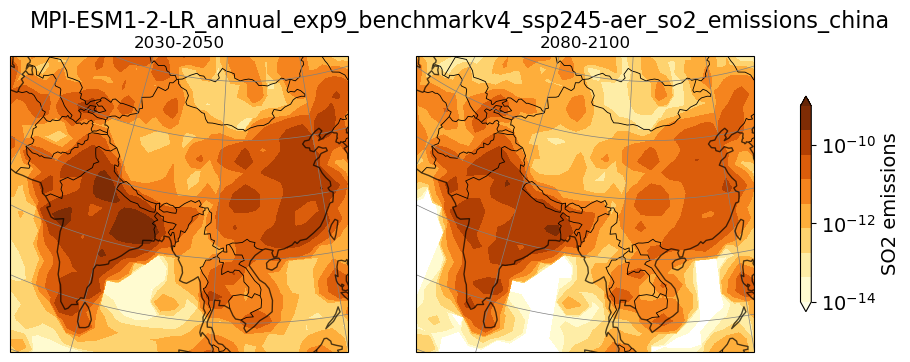

In [16]:
# Relative changes SE-Asia
domain= [70,120, 5, 50]
lims = [-0.75, 0.75]

# 2030-2050
data = {}
plt.figure(figsize=(6,3))
for test, y_hat in y_hat_ds_dict.items():
    y_hat_mean = y_hat.mean('run').values - clim
    y_hat_mean = y_hat_mean[10:].mean(axis=(1,2)) # Removing first 10 years because of sliding window and no historical concatenation
    plt.plot(np.arange(2024, 2100), y_hat_mean, label=test)
    data[f'{test} \n 2030-2050'] = (y_hat.sel(time=slice('2030', '2050')).mean('time').mean('run').values - clim) ### 10 first year to remove (2015-2025)
    data[f'{test} \n 2080-2100'] = (y_hat.sel(time=slice('2080', '2100')).mean('time').mean('run').values - clim) 
plt.legend()
plt.title('ssp245-aer')
plt.ylabel('tas changes')


regional_maps(data,
             lats,
             lons,
             lims=lims,
             title=title_base +'ssp245-aer_tas_changes_china',
              domain=domain,
              cmap='coolwarm',
            label='Temperature changes (K)',
             ncols=2, nrows=None, figsize_per_ax=(6, 4),
             projection = se_asia_proj,
             save_dir=save_dir)

data_dict = {'2030-2050':so2.sel(time=slice('2030', '2050')).mean('time').values,
             '2080-2100':so2.sel(time=slice('2080', '2100')).mean('time').values}
regional_maps(data_dict,
             so2.lat.values,
             so2.lon.values,
             lims=[10e-15, 10e-10],
              domain=domain,
             title=title_base +'ssp245-aer_so2_emissions_china',
              label='SO2 emissions',
             cmap='YlOrBr',
             ncols=2, nrows=None, figsize_per_ax=(6, 4),
             log_scale=True,
              projection = se_asia_proj,
             save_dir=save_dir)

## Aerosols influence on tas regional response (ssp245-aer-ssp370)

In [17]:
so2 = xr.open_dataset(DATASET_DIR / 'MPI-ESM1-2-LR/annual/inputs_ssp245-aer-ssp370_regrid2.nc')['SO2']
y_hat_ds_dict = {'CNN-GRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_ssp245-aer-ssp370_tas_cnn-gru_seq10_mem30_epoch100_bs16_clim.nc')['tas'],
        'Attention-UNet' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_ssp245-aer-ssp370_tas_attention-unet_seq10_mem30_epoch100_bs16_clim.nc')['tas']}

# Open climatology file for pr
clim = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_piControl.nc').mean('member')
clim = clim.sel(time=slice('1850-01-01', '2250-12-31')).mean('time')['tas'].values

ValueError: x and y must have same first dimension, but have shapes (76,) and (77,)

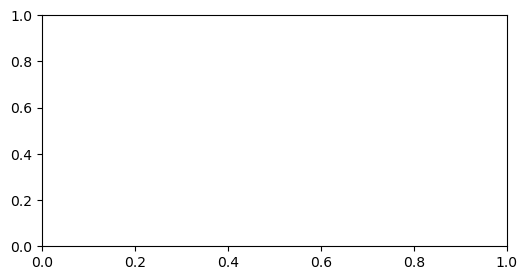

In [19]:
save_dir=None

# 2030-2050
data = {}
plt.figure(figsize=(6,3))
for test, y_hat in y_hat_ds_dict.items():
    y_hat_mean = y_hat.mean('run').values - clim
    y_hat_mean = y_hat_mean.mean(axis=(1,2)) # Already removed
    plt.plot(np.arange(2024, 2100), y_hat_mean, label=test)
    data[f'{test} \n 2030-2050'] = (y_hat.sel(time=slice('2030', '2050')).mean('time').mean('run').values - clim) ### 10 first year to remove (2015-2025)
    data[f'{test} \n 2080-2100'] = (y_hat.sel(time=slice('2080', '2100')).mean('time').mean('run').values - clim) 
plt.legend()
plt.title('ssp245-aer-370')
plt.ylabel('tas changes')


regional_maps(data,
             lats,
             lons,
             lims=lims,
             title=title_base +'ssp245-aer-ssp370_tas_changes_europe',
              domain=domain,
              cmap='coolwarm',
            label='Temperature changes (K)',
             ncols=2, nrows=None, figsize_per_ax=(6, 4),
             projection = europe_proj,
             save_dir=save_dir)

data_dict = {'2030-2050':so2.sel(time=slice('2030', '2050')).mean('time').values,
             '2080-2100':so2.sel(time=slice('2080', '2100')).mean('time').values}
regional_maps(data_dict,
             so2.lat.values,
             so2.lon.values,
             lims=[10e-15, 10e-10],
              domain=domain,
             title=title_base +'ssp245-aer-ssp370_so2_emissions_europe',
              label='SO2 emissions',
             cmap='YlOrBr',
             ncols=2, nrows=None, figsize_per_ax=(6, 4),
             log_scale=True,
              projection = se_asia_proj,
             save_dir=save_dir)